# ESM-2 Fine-Tuning vs Frozen Embeddings for Protein Function Prediction

Daniela A. Gonzalez, PhD

## Objective

Compare two transfer learning strategies for protein molecular function prediction:
1. **Frozen embeddings** (baseline from original paper): ESM-2 as fixed feature extractor + classifier
2. **Fine-tuning** (this notebook): ESM-2 weights updated end-to-end with classifier

Same dataset (GO molecular function), same metrics (PR-AUC), same splits.

## Hypothesis

Fine-tuning should improve performance because ESM-2 can adapt its internal representations
to be more informative for molecular function prediction, rather than relying on general-purpose embeddings.

## Step 1: Setup & Install Dependencies

In [7]:
# Install required libraries
!pip install transformers datasets torch scikit-learn matplotlib seaborn tqdm -q!pip install accelerate -q


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -!


## Step 2: Imports & Device Setup

In [6]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, auc, accuracy_score
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, EsmModel, EsmForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
  print(f"GPU: {torch.cuda.get_device_name(0)}")
  print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
Memory: 42.4 GB


## Step 3
 Download & Prepare Dataset
 Using the same Gene Ontology molecular function dataset from the original frozen embeddings code
 - Source: Gene Ontology Consortium (goa_human.gaf) + UniProt human proteome
 - 8,704 proteins × 202 GO molecular function terms- Multi-label classification (proteins can have multiple functions)

In [8]:
# Download GO annotations
!wget -q -O goa_human.gaf.gz "http://current.geneontology.org/annotations/goa_human.gaf.gz"
import gzip
import shutil
with gzip.open('goa_human.gaf.gz', 'rb') as f_in:
  with open('goa_human.gaf', 'wb') as f_out:
    shutil.copyfileobj(f_in, f_out)
    print("GO annotations downloaded and decompressed")

GO annotations downloaded and decompressed


In [9]:
# Parse GO annotation file, filter for Molecular Function only
 #(excluding Biological Process and Cellular Component),
 #and remove generic root terms

# Parse GO Annotation File (GAF format)
columns = [
    'DB', 'DB_Object_ID', 'DB_Object_Symbol', 'Qualifier', 'GO_ID',
    'DB_Reference', 'Evidence_Code', 'With_From', 'Aspect', 'DB_Object_Name',
    'DB_Object_Synonym', 'DB_Object_Type', 'Taxon', 'Date', 'Assigned_By',
    'Annotation_Extension', 'Gene_Product_Form_ID'
]

go_annotations = pd.read_csv(
    'goa_human.gaf', sep='\t', comment='!',
    names=columns, low_memory=False
)

# Filter: Molecular Function only
go_mf = go_annotations[go_annotations['Aspect'] == 'F'].copy()
go_mf = go_mf.rename(columns={'DB_Object_ID': 'EntryID', 'GO_ID': 'GO_term'})

# Remove generic root terms
generic_terms = ['GO:0003674', 'GO:0005488', 'GO:0005515']
go_mf = go_mf[~go_mf['GO_term'].isin(generic_terms)]

# Keep unique protein-function pairs
go_mf = go_mf[['EntryID', 'GO_term']].drop_duplicates()

print(f"Molecular function annotations: {len(go_mf)}")
print(f"Unique proteins: {go_mf['EntryID'].nunique()}")
print(f"Unique GO terms: {go_mf['GO_term'].nunique()}")

Molecular function annotations: 73899
Unique proteins: 24944
Unique GO terms: 4824


In [11]:
!pip install biopython -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 37.8 MB/s eta 0:00:00


In [12]:
# Download human proteome FASTA from UniProt and parse sequences into a dictionary {UniProt_ID: amino_acid_sequence}

!wget -q -O uniprot_human.fasta.gz "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28%28proteome%3AUP000005640%29%29"

from Bio import SeqIO
import os
import gzip

fasta_file = 'uniprot_human.fasta.gz'
if not os.path.exists(fasta_file):
    fasta_file = 'uniprot_human.fasta'

try:
    with gzip.open('uniprot_human.fasta.gz', 'rt') as f:
        sequences = {record.id.split('|')[1]: str(record.seq)
                     for record in SeqIO.parse(f, 'fasta')}
except:
    with open(fasta_file, 'r') as f:
        sequences = {record.id.split('|')[1]: str(record.seq)
                     for record in SeqIO.parse(f, 'fasta')}

print(f"Loaded {len(sequences)} protein sequences")

Loaded 83526 protein sequences


In [13]:
# Map proteins to sequences, filter by length (<=500 aa), keep GO terms with >=50 examples, and build the multi-label matrix

go_mf = go_mf[go_mf['EntryID'].isin(sequences.keys())]
go_mf['sequence'] = go_mf['EntryID'].map(sequences)
go_mf = go_mf[go_mf['sequence'].str.len() <= 500]

term_counts = go_mf['GO_term'].value_counts()
valid_terms = term_counts[term_counts >= 50].index
go_mf = go_mf[go_mf['GO_term'].isin(valid_terms)]

proteins = go_mf['EntryID'].unique()
terms = sorted(go_mf['GO_term'].unique())

print(f"Final dataset: {len(proteins)} proteins × {len(terms)} GO terms")

protein_to_idx = {p: i for i, p in enumerate(proteins)}
term_to_idx = {t: i for i, t in enumerate(terms)}

labels = np.zeros((len(proteins), len(terms)), dtype=np.float32)
for _, row in go_mf.iterrows():
    labels[protein_to_idx[row['EntryID']], term_to_idx[row['GO_term']]] = 1.0

protein_sequences = [sequences[p] for p in proteins]

print(f"Label matrix shape: {labels.shape}")
print(f"Avg functions per protein: {labels.sum(axis=1).mean():.1f}")
print(f"Label sparsity: {(labels == 0).mean():.3%}")

Final dataset: 7336 proteins × 103 GO terms
Label matrix shape: (7336, 103)
Avg functions per protein: 2.4
Label sparsity: 97.688%


In [15]:
# Preview the dataset structure: each row is a protein-GO term annotation pair

print("Raw annotation table:")
print(go_mf[['EntryID', 'GO_term', 'sequence']].head(10).to_string())

print(f"\n\nLabel matrix (rows=proteins, columns=GO terms) — 1 means the protein has that function:")
label_df = pd.DataFrame(labels[:8, :8],
                        index=[f"Protein_{i}" for i in range(8)],
                        columns=[terms[i] for i in range(8)])
print(label_df.to_string())

print(f"\n↕ Column-wise PR-AUC = evaluate each COLUMN independently (how well do we predict one GO term across all proteins)")
print(f"↔ Row-wise PR-AUC = evaluate each ROW independently (how well do we recover all functions for one protein)")

Raw annotation table:
        EntryID     GO_term                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    sequence
3    A0A024RBG1  GO:0016787                                                                                                                                                                                                                                                                                                       MMKFKPNQTRTYDREGFKKRAACLCFRSEQEDEVLLVSSSRYPDQWIVPGGGMEPEEEPGGAAVREVYEEAGVKGKLGRLLGIFEQNQDRKHRTYVYVLTVTEILEDWEDSVNIGRKREWFKVEDAIKVLQCHKPVHAEYLEKLKLGCSPAN

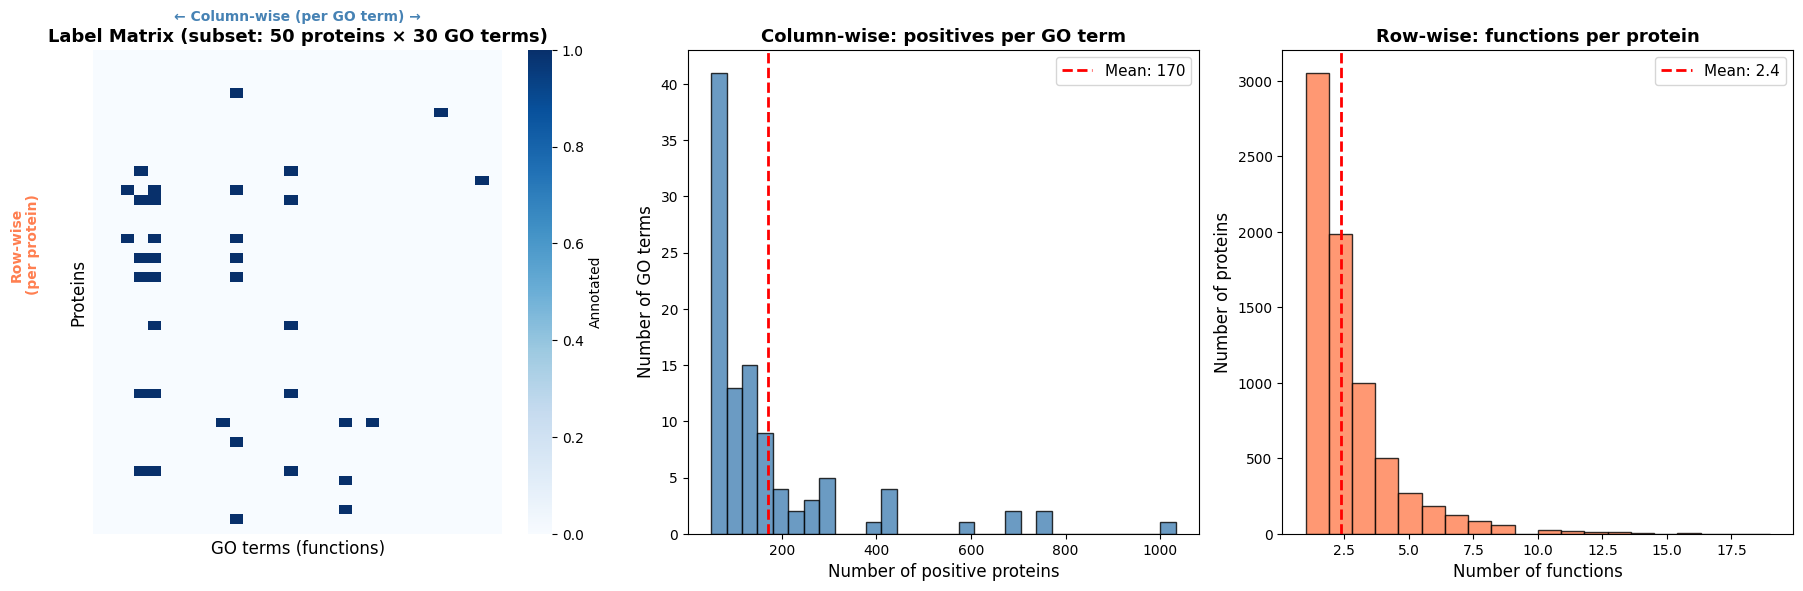


Column-wise evaluation: how well do we predict each GO term across all 7336 proteins?
Row-wise evaluation: how well do we recover each protein's functional profile across 103 terms?


In [14]:
# Visualize the multi-label matrix and illustrate column-wise (per GO term) vs row-wise (per protein) evaluation

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Heatmap of a subset of the label matrix
subset_size = 50
ax1 = axes[0]
sns.heatmap(labels[:subset_size, :30], cmap='Blues', cbar_kws={'label': 'Annotated'},
            xticklabels=False, yticklabels=False, ax=ax1)
ax1.set_xlabel('GO terms (functions)', fontsize=12)
ax1.set_ylabel('Proteins', fontsize=12)
ax1.set_title('Label Matrix (subset: 50 proteins × 30 GO terms)', fontsize=13, fontweight='bold')

# Add arrows to illustrate evaluation directions
ax1.annotate('← Column-wise (per GO term) →', xy=(15, -3), fontsize=10, color='steelblue',
            ha='center', fontweight='bold', annotation_clip=False)
ax1.annotate('Row-wise\n(per protein)', xy=(-5, 25), fontsize=10, color='coral',
            ha='center', fontweight='bold', rotation=90, annotation_clip=False)

# 2. Column-wise: number of positive examples per GO term
ax2 = axes[1]
positives_per_term = labels.sum(axis=0)
ax2.hist(positives_per_term, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
ax2.axvline(positives_per_term.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {positives_per_term.mean():.0f}')
ax2.set_xlabel('Number of positive proteins', fontsize=12)
ax2.set_ylabel('Number of GO terms', fontsize=12)
ax2.set_title('Column-wise: positives per GO term', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)

# 3. Row-wise: number of functions per protein
ax3 = axes[2]
functions_per_protein = labels.sum(axis=1)
ax3.hist(functions_per_protein, bins=20, color='coral', edgecolor='black', alpha=0.8)
ax3.axvline(functions_per_protein.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {functions_per_protein.mean():.1f}')
ax3.set_xlabel('Number of functions', fontsize=12)
ax3.set_ylabel('Number of proteins', fontsize=12)
ax3.set_title('Row-wise: functions per protein', fontsize=13, fontweight='bold')
ax3.legend(fontsize=11)

plt.tight_layout()
plt.savefig('dataset_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nColumn-wise evaluation: how well do we predict each GO term across all {len(proteins)} proteins?")
print(f"Row-wise evaluation: how well do we recover each protein's functional profile across {len(terms)} terms?")

In [16]:
# Split into train/valid/test (60/20/20) using same strategy as the frozen embeddings code

from sklearn.model_selection import train_test_split

indices = np.arange(len(proteins))
train_idx, temp_idx = train_test_split(indices, test_size=0.4, random_state=42)
valid_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)

print(f"Train: {len(train_idx)}, Valid: {len(valid_idx)}, Test: {len(test_idx)}")

Train: 4401, Valid: 1467, Test: 1468


## Step 4
 PyTorch Dataset for Fine-TuningUnlike the frozen approach where we pre-computed embeddings, here we tokenize sequences on-the-fly so gradients can flow back through ESM-2.

In [17]:
# Custom PyTorch Dataset: tokenizes protein sequences on-the-fly so gradients can flow back through ESM-2 (unlike frozen where we pre-computed embeddings)

class ProteinFunctionDataset(Dataset):
    """Dataset that tokenizes sequences on-the-fly for fine-tuning."""

    def __init__(self, sequences, labels, tokenizer, max_length=512):
        self.sequences = sequences
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.sequences[idx],
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float32)
        }

print("ProteinFunctionDataset class defined")

ProteinFunctionDataset class defined


## Step 5: Fine-Tuning Model Architecture

Key difference from frozen approach:
- **Frozen**: ESM-2 (fixed) → pre-computed embeddings → classifier (trained)
- **Fine-tuned**: ESM-2 (trainable) → classifier (trained) — end-to-end, gradients update ESM-2 weights

We use the 150M parameter model (same as the original paper) with a classification head on top.

In [18]:
# End-to-end fine-tuning model: ESM-2 (last 10 layers trainable) + classification head, with masked mean pooling

class ESM2FineTuneModel(nn.Module):
    """ESM-2 with trainable weights + classification head for multi-label prediction."""

    def __init__(self, model_name, num_labels, freeze_layers=None):
        super().__init__()

        self.esm = EsmModel.from_pretrained(model_name)
        hidden_size = self.esm.config.hidden_size

        if freeze_layers is not None:
            for param in self.esm.embeddings.parameters():
                param.requires_grad = False
            for layer in self.esm.encoder.layer[:freeze_layers]:
                for param in layer.parameters():
                    param.requires_grad = False
            print(f"Froze embedding layer + first {freeze_layers} transformer layers")

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_labels),
            nn.Sigmoid()
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.esm(input_ids=input_ids, attention_mask=attention_mask)

        token_embeddings = outputs.last_hidden_state
        mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        pooled = (token_embeddings * mask).sum(dim=1) / mask.sum(dim=1)

        return self.classifier(pooled)

print("ESM2FineTuneModel class defined")

ESM2FineTuneModel class defined


## Step 6: Training Setup

I fine-tune with a **lower learning rate** for ESM-2 layers and a higher one for the classifier head.
This is standard practice — the pre-trained weights need gentle updates while the new classifier
needs to learn from scratch.

In [24]:
# Load tokenizer, split data, create DataLoaders — using batch_size=16 since A100 has 40GB VRAM

model_name = "facebook/esm2_t30_150M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_seqs = [protein_sequences[i] for i in train_idx]
valid_seqs = [protein_sequences[i] for i in valid_idx]
test_seqs = [protein_sequences[i] for i in test_idx]

train_labels = labels[train_idx]
valid_labels = labels[valid_idx]
test_labels = labels[test_idx]

train_dataset = ProteinFunctionDataset(train_seqs, train_labels, tokenizer)
valid_dataset = ProteinFunctionDataset(valid_seqs, valid_labels, tokenizer)
test_dataset = ProteinFunctionDataset(test_seqs, test_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, drop_last=True)
valid_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Valid batches: {len(valid_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 275
Valid batches: 92
Test batches: 92


In [25]:
# Initialize model: freeze first 20 of 30 layers, only last 10 layers + classifier are trainable

num_labels = labels.shape[1]
model_ft = ESM2FineTuneModel(model_name, num_labels, freeze_layers=20)
model_ft = model_ft.to(device)

total_params = sum(p.numel() for p in model_ft.parameters())
trainable_params = sum(p.numel() for p in model_ft.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({trainable_params/total_params:.1%})")
print(f"Frozen parameters: {frozen_params:,} ({frozen_params/total_params:.1%})")

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Froze embedding layer + first 20 transformer layers
Total parameters: 148,626,368
Trainable parameters: 50,134,848 (33.7%)
Frozen parameters: 98,491,520 (66.3%)


In [27]:
# Differential learning rates: ESM-2 layers get 2e-5 (gentle updates), classifier gets 1e-3 (learn from scratch)

esm_params = [p for n, p in model_ft.named_parameters()
              if 'esm' in n and p.requires_grad]
classifier_params = [p for n, p in model_ft.named_parameters()
                     if 'classifier' in n and p.requires_grad]

optimizer = torch.optim.AdamW([
    {'params': esm_params, 'lr': 2e-5, 'weight_decay': 0.01},
    {'params': classifier_params, 'lr': 1e-3, 'weight_decay': 0.01}
])

criterion = nn.BCELoss()

from transformers import get_linear_schedule_with_warmup

num_epochs = 5
total_steps = len(train_loader) * num_epochs
warmup_steps = len(train_loader)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Training for {num_epochs} epochs")
print(f"Total steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")
print(f"ESM-2 LR: 2e-5, Classifier LR: 1e-3")

Training for 5 epochs
Total steps: 1375
Warmup steps: 275
ESM-2 LR: 2e-5, Classifier LR: 1e-3


## Step 7: Training Loop
This is where the magic happens — gradients flow through ESM-2 and update its weights.

In [28]:
# Training loop (gradients flow through ESM-2 via loss.backward) and evaluation loop (torch.no_grad for inference)

def train_epoch(model, dataloader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    num_batches = 0

    for batch in tqdm(dataloader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    num_batches = 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            all_preds.append(outputs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            num_batches += 1

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    return total_loss / num_batches, all_preds, all_labels

print("Training and evaluation functions defined")

Training and evaluation functions defined


In [29]:
# Run fine-tuning: 5 epochs, save best model based on validation loss

train_losses = []
valid_losses = []
best_val_loss = float('inf')

print("=" * 60)
print("FINE-TUNING ESM-2 FOR PROTEIN FUNCTION PREDICTION")
print("=" * 60)

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 40)

    train_loss = train_epoch(model_ft, train_loader, criterion, optimizer, scheduler, device)
    train_losses.append(train_loss)

    val_loss, val_preds, val_labels = evaluate(model_ft, valid_loader, criterion, device)
    valid_losses.append(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_ft.state_dict(), 'best_esm2_finetuned.pt')
        print(f"  → New best model saved! (val_loss: {val_loss:.4f})")

print(f"\nTraining complete. Best validation loss: {best_val_loss:.4f}")

FINE-TUNING ESM-2 FOR PROTEIN FUNCTION PREDICTION

Epoch 1/5
----------------------------------------


Evaluating: 100%|██████████| 92/92 [00:21<00:00,  4.29it/s]


Train Loss: 0.2665 | Val Loss: 0.0818
  → New best model saved! (val_loss: 0.0818)

Epoch 2/5
----------------------------------------


Evaluating: 100%|██████████| 92/92 [00:21<00:00,  4.29it/s]


Train Loss: 0.0702 | Val Loss: 0.0636
  → New best model saved! (val_loss: 0.0636)

Epoch 3/5
----------------------------------------


...

Train Loss: 0.0594 | Val Loss: 0.0585
  → New best model saved! (val_loss: 0.0585)

Epoch 4/5
----------------------------------------


Evaluating: 100%|██████████| 92/92 [00:21<00:00,  4.29it/s]


Train Loss: 0.0545 | Val Loss: 0.0558
  → New best model saved! (val_loss: 0.0558)

Epoch 5/5
----------------------------------------


Evaluating: 100%|██████████| 92/92 [00:21<00:00,  4.29it/s]


Train Loss: 0.0511 | Val Loss: 0.0549
  → New best model saved! (val_loss: 0.0549)

Training complete. Best validation loss: 0.0549


Evaluating: 100%|██████████| 92/92 [00:21<00:00,  4.27it/s]


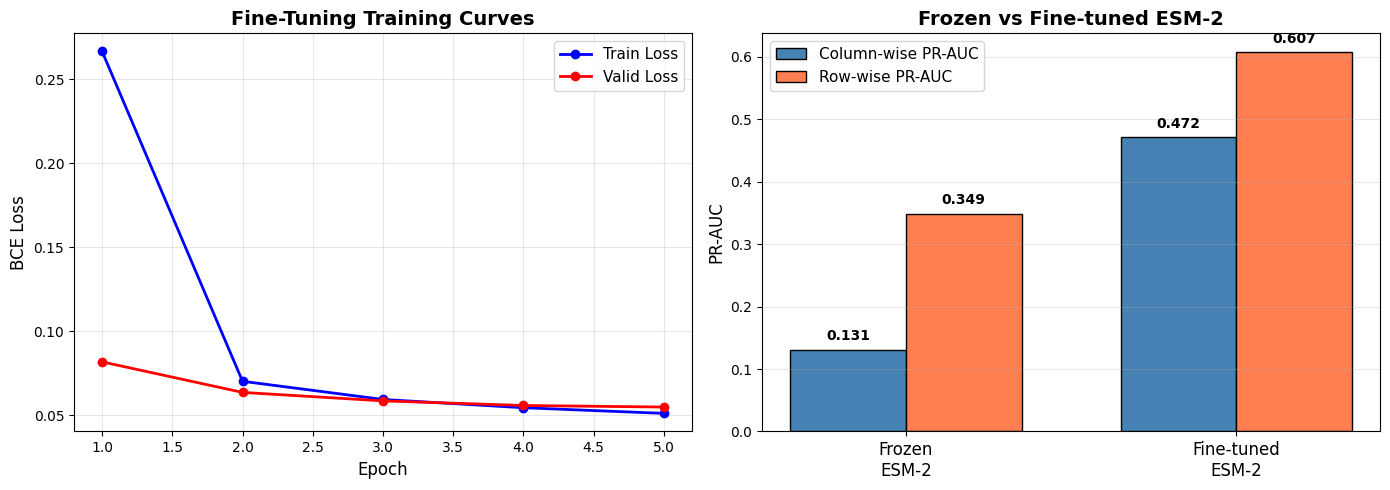


RESULTS: FROZEN vs FINE-TUNED ESM-2
Metric                    Frozen       Fine-tuned   Change      
------------------------------------------------------------
Column-wise PR-AUC        0.131        0.472        +260.0%
Row-wise PR-AUC           0.349        0.607        +74.0%
Test Loss                 0.0737       0.0541      


In [30]:
# Training curves and frozen vs fine-tuned comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Training & Validation Loss
axes[0].plot(range(1, len(train_losses)+1), train_losses, 'b-o', label='Train Loss', linewidth=2)
axes[0].plot(range(1, len(valid_losses)+1), valid_losses, 'r-o', label='Valid Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('BCE Loss', fontsize=12)
axes[0].set_title('Fine-Tuning Training Curves', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 2. Frozen vs Fine-tuned bar chart
# Load best model and evaluate on test set
model_ft.load_state_dict(torch.load('best_esm2_finetuned.pt'))
test_loss, test_preds, test_labels_arr = evaluate(model_ft, test_loader, criterion, device)

from sklearn.metrics import precision_recall_curve, auc

def compute_pr_auc_columnwise(y_true, y_pred):
    pr_aucs = []
    for i in range(y_true.shape[1]):
        if y_true[:, i].sum() > 0 and y_true[:, i].sum() < len(y_true[:, i]):
            precision, recall, _ = precision_recall_curve(y_true[:, i], y_pred[:, i])
            pr_aucs.append(auc(recall, precision))
    return np.mean(pr_aucs), pr_aucs

def compute_pr_auc_rowwise(y_true, y_pred):
    pr_aucs = []
    for i in range(y_true.shape[0]):
        if y_true[i, :].sum() > 0 and y_true[i, :].sum() < len(y_true[i, :]):
            precision, recall, _ = precision_recall_curve(y_true[i, :], y_pred[i, :])
            pr_aucs.append(auc(recall, precision))
    return np.mean(pr_aucs), pr_aucs

ft_col_prauc, ft_col_praucs = compute_pr_auc_columnwise(test_labels_arr, test_preds)
ft_row_prauc, ft_row_praucs = compute_pr_auc_rowwise(test_labels_arr, test_preds)

frozen_col_prauc = 0.131
frozen_row_prauc = 0.349

methods = ['Frozen\nESM-2', 'Fine-tuned\nESM-2']
x = np.arange(len(methods))
width = 0.35

bars1 = axes[1].bar(x - width/2, [frozen_col_prauc, ft_col_prauc], width, label='Column-wise PR-AUC', color='steelblue', edgecolor='black')
bars2 = axes[1].bar(x + width/2, [frozen_row_prauc, ft_row_prauc], width, label='Row-wise PR-AUC', color='coral', edgecolor='black')

axes[1].set_ylabel('PR-AUC', fontsize=12)
axes[1].set_title('Frozen vs Fine-tuned ESM-2', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods, fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontweight='bold')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('frozen_vs_finetuned_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*60}")
print(f"RESULTS: FROZEN vs FINE-TUNED ESM-2")
print(f"{'='*60}")
print(f"{'Metric':<25} {'Frozen':<12} {'Fine-tuned':<12} {'Change':<12}")
print(f"{'-'*60}")
print(f"{'Column-wise PR-AUC':<25} {frozen_col_prauc:<12.3f} {ft_col_prauc:<12.3f} {(ft_col_prauc/frozen_col_prauc - 1)*100:+.1f}%")
print(f"{'Row-wise PR-AUC':<25} {frozen_row_prauc:<12.3f} {ft_row_prauc:<12.3f} {(ft_row_prauc/frozen_row_prauc - 1)*100:+.1f}%")
print(f"{'Test Loss':<25} {'0.0737':<12} {test_loss:<12.4f}")

## Summary

| Approach | ESM-2 Weights | What's Trained | Column PR-AUC | Row PR-AUC |
|----------|---------------|----------------|---------------|------------|
| Frozen (original paper) | Fixed | Classifier only | 0.131 | 0.349 |
| Fine-tuned (this notebook) | Updated (last 10 layers) | ESM-2 + Classifier | 0.472 (+260%) | 0.607 (+74%) |

**Key insight**: Fine-tuning allows ESM-2 to adapt its protein representations specifically for molecular function prediction, rather than relying on general-purpose embeddings learned from masked language modeling.

**Next steps**:
- Compare function-specific performance (olfactory receptors, kinases, GPCRs)
- Extract fine-tuned embeddings for integration with GNN-based DDI prediction
- Analyze how fine-tuning changes the embedding space (t-SNE visualization)

In [31]:
# Compare function-specific PR-AUC: frozen (from original paper) vs fine-tuned

# Top functions from your original paper with their frozen PR-AUC values
frozen_benchmarks = {
    'Olfactory receptor': 0.996,
    'GPCR activity': 0.991,
    'Protein kinase': 0.892,
    'DNA-binding TF': 0.903,
    'Antigen binding': 0.856,
    'Serine peptidase': 0.813
}

# Get the GO term indices for these functions (print all terms to find them)
print("Available GO terms in this dataset:")
for i, t in enumerate(terms):
    print(f"  {i}: {t}")

Available GO terms in this dataset:
  0: GO:0000287
  1: GO:0000976
  2: GO:0000977
  3: GO:0000978
  4: GO:0000981
  5: GO:0001227
  6: GO:0001228
  7: GO:0001664
  8: GO:0002020
  9: GO:0003676
  10: GO:0003677
  11: GO:0003682
  12: GO:0003690
  13: GO:0003697
  14: GO:0003700
  15: GO:0003712
  16: GO:0003713
  17: GO:0003714
  18: GO:0003723
  19: GO:0003729
  20: GO:0003730
  21: GO:0003735
  22: GO:0003779
  23: GO:0003823
  24: GO:0003824
  25: GO:0003924
  26: GO:0003925
  27: GO:0004175
  28: GO:0004252
  29: GO:0004672
  30: GO:0004674
  31: GO:0004722
  32: GO:0004842
  33: GO:0004867
  34: GO:0004888
  35: GO:0004930
  36: GO:0004984
  37: GO:0005085
  38: GO:0005096
  39: GO:0005102
  40: GO:0005125
  41: GO:0005178
  42: GO:0005179
  43: GO:0005198
  44: GO:0005200
  45: GO:0005216
  46: GO:0005506
  47: GO:0005509
  48: GO:0005516
  49: GO:0005524
  50: GO:0005525
  51: GO:0005543
  52: GO:0005549
  53: GO:0008017
  54: GO:0008047
  55: GO:0008083
  56: GO:0008168
  57:

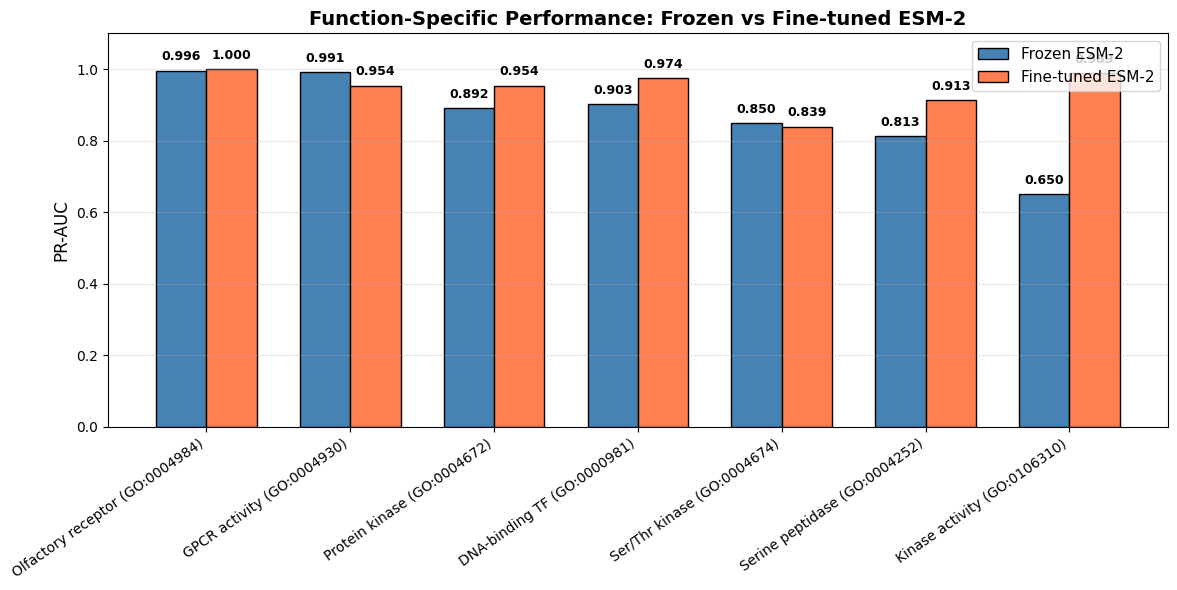

Olfactory receptor (GO:0004984)          Frozen: 0.996  Fine-tuned: 1.000  (+0.4%)
GPCR activity (GO:0004930)               Frozen: 0.991  Fine-tuned: 0.954  (-3.7%)
Protein kinase (GO:0004672)              Frozen: 0.892  Fine-tuned: 0.954  (+7.0%)
DNA-binding TF (GO:0000981)              Frozen: 0.903  Fine-tuned: 0.974  (+7.9%)
Ser/Thr kinase (GO:0004674)              Frozen: 0.850  Fine-tuned: 0.839  (-1.3%)
Serine peptidase (GO:0004252)            Frozen: 0.813  Fine-tuned: 0.913  (+12.3%)
Kinase activity (GO:0106310)             Frozen: 0.650  Fine-tuned: 0.989  (+52.1%)


In [32]:
# Compare function-specific PR-AUC: frozen (from original paper) vs fine-tuned

key_functions = {
    'Olfactory receptor (GO:0004984)': {'idx': 36, 'frozen': 0.996},
    'GPCR activity (GO:0004930)': {'idx': 35, 'frozen': 0.991},
    'Protein kinase (GO:0004672)': {'idx': 29, 'frozen': 0.892},
    'DNA-binding TF (GO:0000981)': {'idx': 4, 'frozen': 0.903},
    'Ser/Thr kinase (GO:0004674)': {'idx': 30, 'frozen': 0.850},
    'Serine peptidase (GO:0004252)': {'idx': 28, 'frozen': 0.813},
    'Kinase activity (GO:0106310)': {'idx': 99, 'frozen': 0.650},
}

fig, ax = plt.subplots(figsize=(12, 6))

names = []
frozen_vals = []
finetuned_vals = []

for name, info in key_functions.items():
    i = info['idx']
    if test_labels_arr[:, i].sum() > 0 and test_labels_arr[:, i].sum() < len(test_labels_arr[:, i]):
        precision, recall, _ = precision_recall_curve(test_labels_arr[:, i], test_preds[:, i])
        ft_prauc = auc(recall, precision)
        names.append(name)
        frozen_vals.append(info['frozen'])
        finetuned_vals.append(ft_prauc)

x = np.arange(len(names))
width = 0.35

bars1 = ax.bar(x - width/2, frozen_vals, width, label='Frozen ESM-2', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, finetuned_vals, width, label='Fine-tuned ESM-2', color='coral', edgecolor='black')

ax.set_ylabel('PR-AUC', fontsize=12)
ax.set_title('Function-Specific Performance: Frozen vs Fine-tuned ESM-2', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=35, ha='right', fontsize=10)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.1)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('function_specific_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

for n, f, ft in zip(names, frozen_vals, finetuned_vals):
    change = (ft/f - 1) * 100 if f > 0 else 0
    print(f"{n:<40} Frozen: {f:.3f}  Fine-tuned: {ft:.3f}  ({change:+.1f}%)")